这是预处理步骤中的第二步，由于暂时使用的是stpainter预处理过的数据，所以代码还没有补齐，后续再进行修改

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
import scanpy as sc
import cv2

# ==========================================
# File paths
# ==========================================
transcripts_path = "/root/autodl-tmp/xe_raw_data/PRAD_NSCLC_CESC/PRAD/transcripts.parquet"
boundaries_path = "/root/autodl-tmp/xe_raw_data/PRAD_NSCLC_CESC/PRAD/cell_boundaries.parquet"
nucleus_path = "/root/autodl-tmp/xe_raw_data/PRAD_NSCLC_CESC/PRAD/nucleus_boundaries.parquet"
h5ad_path = "/root/autodl-tmp/xe_raw_data/data/st_PRAD_imputed.h5ad"

# ==========================================
# Step 1: Load Imputed Reference
# ==========================================
adata_imputed = ad.read_h5ad(h5ad_path)
imputed_genes = adata_imputed.var_names.tolist()
imputed_cells = set(adata_imputed.obs['cell_id'])

# ==========================================
# Step 2: Process Transcripts to Bins (2um)
# ==========================================
df_trans = pd.read_parquet(transcripts_path, columns=['feature_name', 'x_location', 'y_location', 'is_gene'])
df_trans = df_trans[(df_trans['is_gene']) & (df_trans['feature_name'].isin(imputed_genes))]

df_trans['bin_x'] = np.floor(df_trans['x_location'] / 2.0).astype(int)
df_trans['bin_y'] = np.floor(df_trans['y_location'] / 2.0).astype(int)
df_trans['bin_id'] = df_trans['bin_x'].astype(str) + "_" + df_trans['bin_y'].astype(str)

bin_ids, bin_uniques = pd.factorize(df_trans['bin_id'])
gene_ids, gene_uniques = pd.factorize(df_trans['feature_name'])

# Align gene indices to imputed data
gene_map = {g: i for i, g in enumerate(imputed_genes)}
aligned_gene_ids = np.array([gene_map[gene_uniques[i]] for i in gene_ids])

X_raw = sp.coo_matrix((np.ones(len(df_trans)), (bin_ids, aligned_gene_ids)), 
                      shape=(len(bin_uniques), len(imputed_genes))).tocsr()

raw_hd_adata = ad.AnnData(X=X_raw)
raw_hd_adata.obs_names = bin_uniques
raw_hd_adata.var_names = imputed_genes
sc.pp.calculate_qc_metrics(raw_hd_adata, inplace=True)

# Extract coordinates for bins
coords = np.array([list(map(int, b.split('_'))) for b in raw_hd_adata.obs_names])
raw_hd_adata.obsm['spatial'] = coords * 2  # Spatial coordinates in original scale
bin_x_coords, bin_y_coords = coords[:, 0], coords[:, 1]

# ==========================================
# Step 3: Rasterize Cell and Nucleus Boundaries
# ==========================================
max_x, max_y = bin_x_coords.max() + 1, bin_y_coords.max() + 1
cell_mask = np.zeros((max_y, max_x), dtype=np.int32) 
nucleus_mask = np.zeros((max_y, max_x), dtype=np.int32)

df_bounds = pd.read_parquet(boundaries_path)
df_nucleus = pd.read_parquet(nucleus_path)

unique_cells = df_bounds['cell_id'].unique()
cell_id_to_int = {cid: i + 1 for i, cid in enumerate(unique_cells)}
int_to_cell_id = {i + 1: cid for i, cid in enumerate(unique_cells)}
int_to_cell_id[0] = "0"

def rasterize_polygons(df, mask, id_map):
    df['grid_x'] = (df['vertex_x'] / 2.0).astype(int)
    df['grid_y'] = (df['vertex_y'] / 2.0).astype(int)
    for cid, group in df.groupby('cell_id'):
        if cid not in id_map:
            continue
        pts = group[['grid_x', 'grid_y']].values.reshape((-1, 1, 2)).astype(np.int32)
        cv2.fillPoly(mask, [pts], color=id_map[cid])

rasterize_polygons(df_bounds, cell_mask, cell_id_to_int)
rasterize_polygons(df_nucleus, nucleus_mask, cell_id_to_int)

raw_hd_adata.obs['cell_id_int'] = cell_mask[bin_y_coords, bin_x_coords]
raw_hd_adata.obs['nucleus_id_int'] = nucleus_mask[bin_y_coords, bin_x_coords]

# ==========================================
# Step 4: Synthesize Missing Nuclei
# ==========================================
raw_hd_adata.obs['synthesis_nucleus_id_int'] = raw_hd_adata.obs['nucleus_id_int'].copy()

cells_with_soma = set(raw_hd_adata.obs['cell_id_int'][raw_hd_adata.obs['cell_id_int'] > 0].unique())
cells_with_nuc = set(raw_hd_adata.obs['nucleus_id_int'][raw_hd_adata.obs['nucleus_id_int'] > 0].unique())
missing_nucs = cells_with_soma - cells_with_nuc

raw_hd_adata.obs['x'] = bin_x_coords
raw_hd_adata.obs['y'] = bin_y_coords

for cid in missing_nucs:
    cell_mask_idx = np.where(raw_hd_adata.obs['cell_id_int'] == cid)[0]
    if len(cell_mask_idx) == 0:
        continue
        
    cell_x = raw_hd_adata.obs['x'].iloc[cell_mask_idx].values
    cell_y = raw_hd_adata.obs['y'].iloc[cell_mask_idx].values
    
    center_x, center_y = cell_x.mean(), cell_y.mean()
    distances_sq = (cell_x - center_x)**2 + (cell_y - center_y)**2
    
    num_to_select = min(4, len(cell_mask_idx))
    closest_local_indices = np.argsort(distances_sq)[:num_to_select]
    closest_global_indices = cell_mask_idx[closest_local_indices]
    
    raw_hd_adata.obs.iloc[closest_global_indices, raw_hd_adata.obs.columns.get_loc('synthesis_nucleus_id_int')] = cid

raw_hd_adata.obs.drop(columns=['x', 'y'], inplace=True)

raw_hd_adata.obs['cell_id'] = raw_hd_adata.obs['cell_id_int'].map(int_to_cell_id).astype('category')
raw_hd_adata.obs['nucleus_id'] = raw_hd_adata.obs['nucleus_id_int'].map(int_to_cell_id).astype('category')
raw_hd_adata.obs['synthesis_nucleus_id'] = raw_hd_adata.obs['synthesis_nucleus_id_int'].map(int_to_cell_id).astype('category')

# ==========================================
# Step 5: Vectorized Distribution via Sparse Matrix Multiplication
# ==========================================
obs_df = raw_hd_adata.obs
valid_mask = obs_df['cell_id'].isin(imputed_cells).values
valid_bin_indices = np.where(valid_mask)[0]
valid_cell_ids = obs_df['cell_id'].values[valid_mask]

# 1. Map cell_ids to adata_imputed row indices
imputed_id_to_idx = {cid: i for i, cid in enumerate(adata_imputed.obs['cell_id'])}
target_cell_indices = np.array([imputed_id_to_idx[cid] for cid in valid_cell_ids])

# 2. Calculate spatial weights (raw bin sums)
bin_raw_sums = np.asarray(raw_hd_adata.X.sum(axis=1)).flatten()
valid_bin_weights = bin_raw_sums[valid_bin_indices]

# 3. Normalize weights per cell using vectorized groupby
weight_df = pd.DataFrame({'cell_idx': target_cell_indices, 'weight': valid_bin_weights})
cell_weight_sums = weight_df.groupby('cell_idx')['weight'].transform('sum').values

# Handle cells where total raw weight is 0 (distribute uniformly)
zero_mask = cell_weight_sums == 0
if zero_mask.any():
    bin_counts = weight_df.groupby('cell_idx')['weight'].transform('count').values
    valid_bin_weights[zero_mask] = 1.0
    cell_weight_sums[zero_mask] = bin_counts[zero_mask]

normalized_weights = valid_bin_weights / cell_weight_sums

# 4. Construct Sparse Mapping Matrix M (n_bins x n_imputed_cells)
n_bins = raw_hd_adata.n_obs
n_imp_cells = adata_imputed.n_obs
M = sp.csr_matrix(
    (normalized_weights, (valid_bin_indices, target_cell_indices)), 
    shape=(n_bins, n_imp_cells),
    dtype=np.float32
)

# 5. Distribute expression via Sparse Matrix Multiplication
# This single operation replaces the entire python loop
X_imputed_distributed = M @ adata_imputed.X

# 6. Zero out original expression for imputed bins and merge
keep_mask = (~valid_mask).astype(np.float32)
Keep_Diag = sp.diags(keep_mask)
X_raw_kept = Keep_Diag @ raw_hd_adata.X

raw_hd_adata.X = X_raw_kept + X_imputed_distributed

# Clean up
raw_hd_adata.obs.drop(columns=['cell_id_int', 'nucleus_id_int', 'synthesis_nucleus_id_int'], inplace=True, errors='ignore')

In [2]:
raw_hd_adata.write_h5ad('/root/autodl-tmp/xe_raw_data/PRAD_NSCLC_CESC/PRAD/PRAD_visium_hd_2um.h5ad')

In [3]:
raw_hd_adata

AnnData object with n_obs × n_vars = 5465059 × 10000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'cell_id', 'nucleus_id', 'synthesis_nucleus_id'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

ROI 区域内总细胞数量: 836
ROI 区域内无细胞核标签的细胞数量: 16


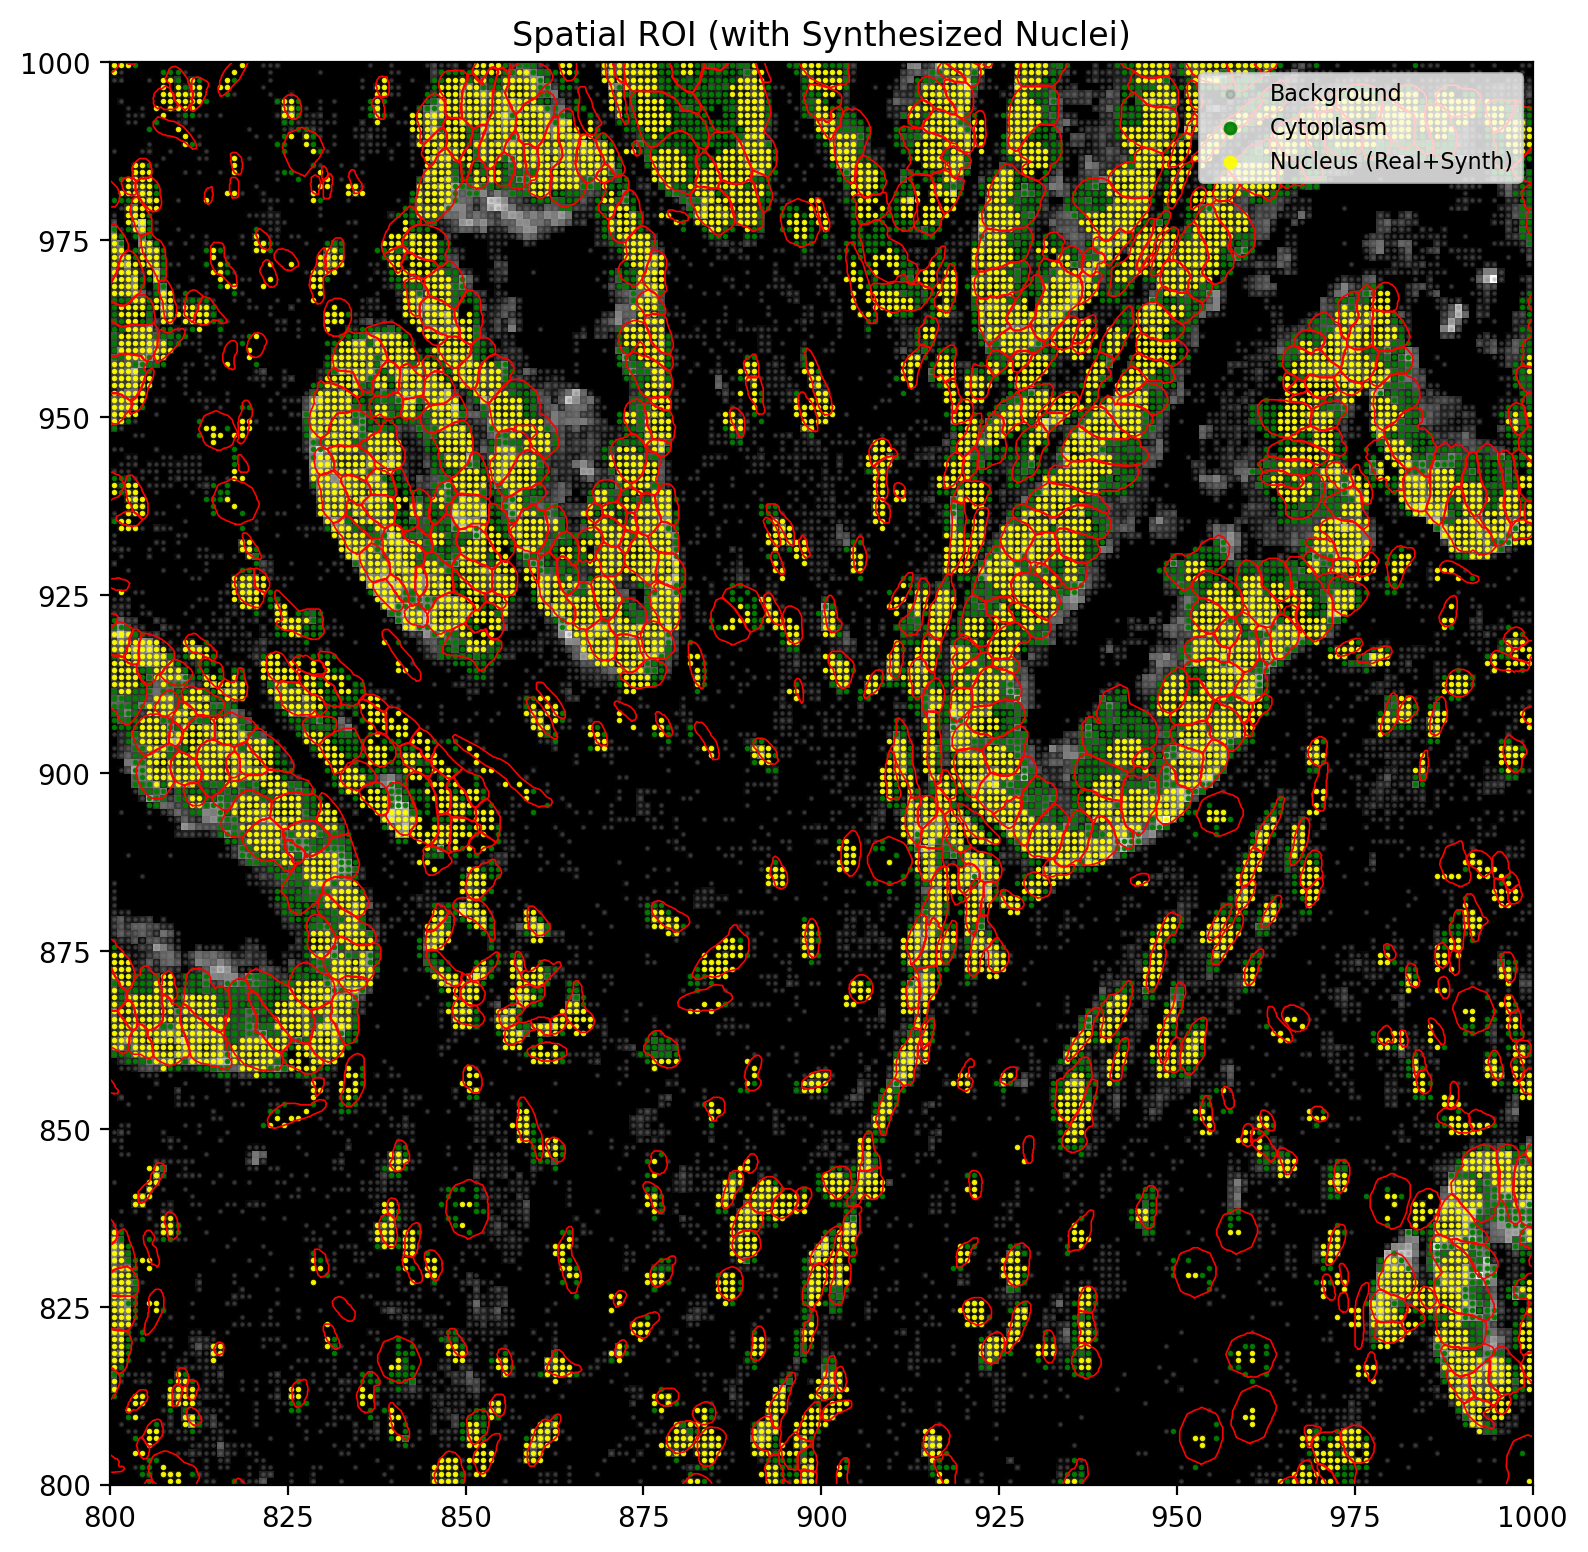

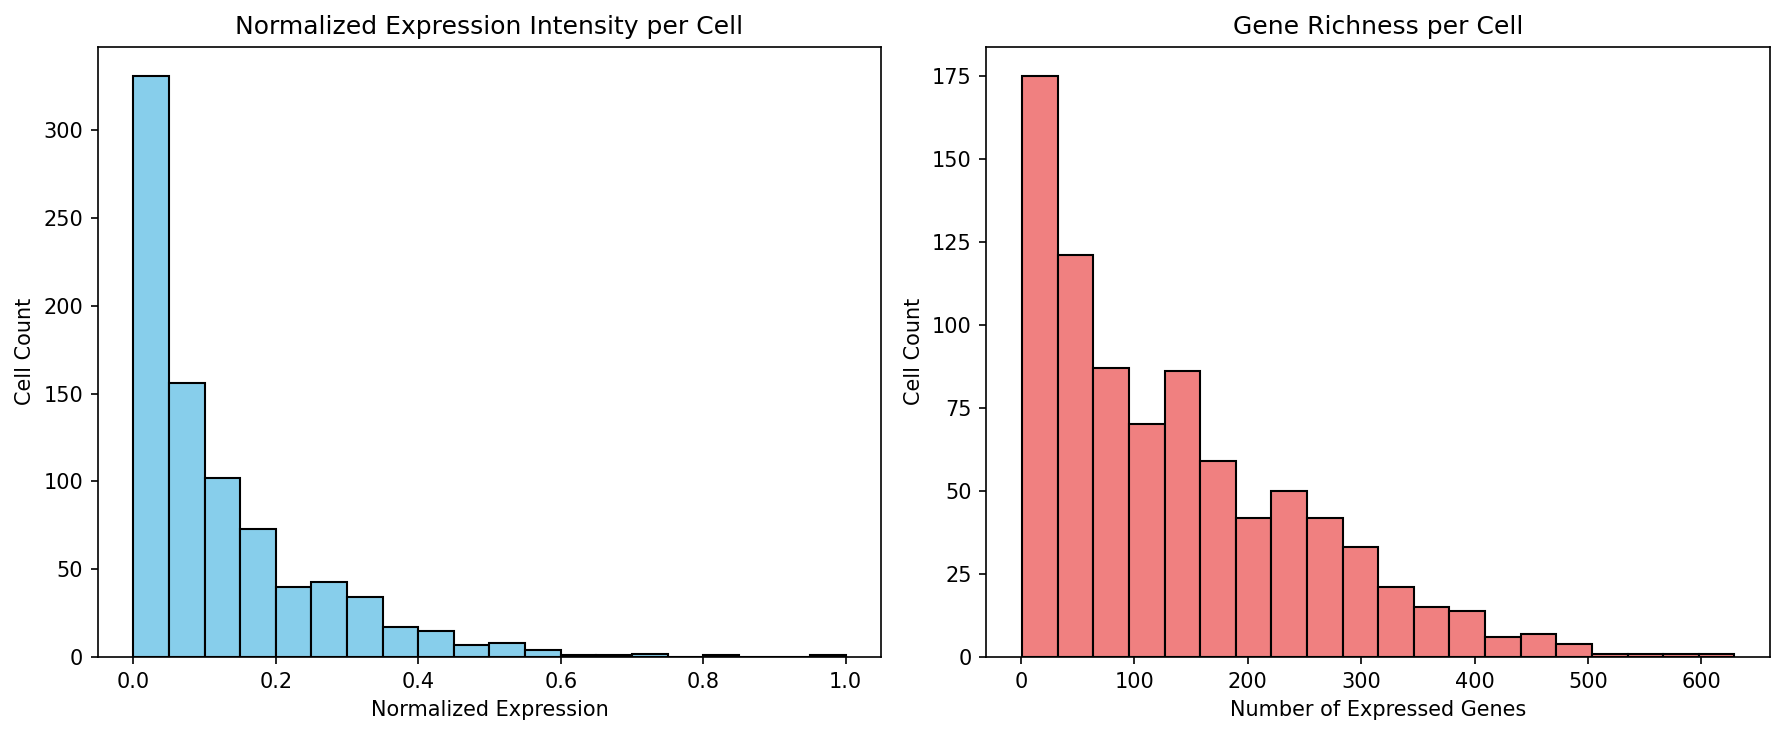

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 定义 ROI 范围 (Bin 坐标系)
x_min, x_max = 800, 1000
y_min, y_max = 800, 1000

# Step 1: 过滤 ROI 内的 Bin 并提取数据
bin_x = (raw_hd_adata.obsm['spatial'][:, 0] / 2).astype(int)
bin_y = (raw_hd_adata.obsm['spatial'][:, 1] / 2).astype(int)
in_roi = (bin_x >= x_min) & (bin_x < x_max) & (bin_y >= y_min) & (bin_y < y_max)

roi_adata = raw_hd_adata[in_roi]
is_cell_roi = roi_adata.obs['cell_id'] != "0"
cell_adata = roi_adata[is_cell_roi]

# Step 2 & 3: 聚合单细胞数据并统计指标
unique_cells = cell_adata.obs['cell_id'].unique()
total_cells = len(unique_cells)
no_nucleus_count = 0

cell_expr_sums = []
cell_gene_counts = []

for cid in unique_cells:
    mask = cell_adata.obs['cell_id'] == cid
    
    if not (cell_adata.obs['synthesis_nucleus_id'][mask] != "0").any():
        no_nucleus_count += 1
        
    cell_expr_vector = cell_adata[mask].X.sum(axis=0)
    cell_expr_vector = np.asarray(cell_expr_vector).flatten()
    
    cell_expr_sums.append(cell_expr_vector.sum())
    cell_gene_counts.append((cell_expr_vector > 0).sum())

print(f"ROI 区域内总细胞数量: {total_cells}")
print(f"ROI 区域内无细胞核标签的细胞数量: {no_nucleus_count}")

# 表达量归一化
cell_expr_sums = np.array(cell_expr_sums)
if total_cells > 0:
    e_min, e_max = cell_expr_sums.min(), cell_expr_sums.max()
    norm_expr = (cell_expr_sums - e_min) / (e_max - e_min + 1e-9)
else:
    norm_expr = np.array([])

# ==========================================
# Figure 1: 单独输出 Spatial ROI 空间可视化
# ==========================================
plt.figure(figsize=(8, 8), dpi=200)

rx, ry = bin_x[in_roi], bin_y[in_roi]
r_counts = roi_adata.obs['total_counts'].values
r_cell = roi_adata.obs['cell_id'].values
r_nuc = roi_adata.obs['synthesis_nucleus_id'].values

# 背景表达量热图
roi_img = np.zeros((y_max - y_min, x_max - x_min), dtype=np.float32)
roi_img[ry - y_min, rx - x_min] = r_counts
roi_img_norm = (roi_img - roi_img.min()) / (roi_img.max() - roi_img.min() + 1e-9)

# extent 设定了图像的物理坐标范围
plt.imshow(roi_img_norm, cmap='gray', origin='lower', extent=[x_min, x_max, y_min, y_max])

# 严格的互斥逻辑
is_bg = r_cell == "0"
is_nuc = r_nuc != "0"
is_cell = (r_cell != "0") & (r_nuc == "0") # 细胞核为0且细胞标记不为0

# 绘制散点 (注意：+0.5 是为了让散点完美对齐 imshow 的像素中心；缩小 s=1 防止颜色溢出)
plt.scatter(rx[is_bg] + 0.5, ry[is_bg] + 0.5, c='gray', s=0.5, alpha=0.3, label='Background')
plt.scatter(rx[is_cell] + 0.5, ry[is_cell] + 0.5, c='green', s=1, alpha=0.9, label='Cytoplasm')
plt.scatter(rx[is_nuc] + 0.5, ry[is_nuc] + 0.5, c='yellow', s=1, alpha=0.9, label='Nucleus (Real+Synth)')

# 绘制细胞边界 (调细线宽 linewidth=0.6，使其更精准)
for cell_id, group in df_bounds.groupby('cell_id'):
    vx = group['vertex_x'].values / 2
    vy = group['vertex_y'].values / 2
    if vx.max() < x_min or vx.min() > x_max or vy.max() < y_min or vy.min() > y_max:
        continue
    # 同样 +0.5 对齐像素
    plt.plot(np.append(vx, vx[0]) + 0.5, np.append(vy, vy[0]) + 0.5, color='red', linewidth=0.6)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal')
plt.title("Spatial ROI (with Synthesized Nuclei)")
plt.legend(loc='upper right', fontsize=8, markerscale=4) # markerscale放大图例中的点
plt.tight_layout()
plt.show()

# ==========================================
# Figure 2: 两个直方图作为组图输出
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# --- 子图 1: 归一化表达强度直方图 ---
if len(norm_expr) > 0:
    axes[0].hist(norm_expr, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title("Normalized Expression Intensity per Cell")
axes[0].set_xlabel("Normalized Expression")
axes[0].set_ylabel("Cell Count")

# --- 子图 2: 基因丰富度直方图 ---
if len(cell_gene_counts) > 0:
    axes[1].hist(cell_gene_counts, bins=20, color='lightcoral', edgecolor='black')
axes[1].set_title("Gene Richness per Cell")
axes[1].set_xlabel("Number of Expressed Genes")
axes[1].set_ylabel("Cell Count")

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
import anndata as ad

# Step 1: Count annotated cells in parquet
parquet_path = '/root/autodl-tmp/xe_raw_data/PRAD_NSCLC_CESC/PRAD/cells.parquet'
df_cells = pd.read_parquet(parquet_path, columns=['cell_id'])
num_annotated_cells = len(df_cells)

# Step 2: Count retained cells in h5ad
h5ad_path = '/root/autodl-tmp/xe_raw_data/data/st_PRAD_imputed.h5ad'
adata = ad.read_h5ad(h5ad_path)
num_retained_cells = adata.n_obs

# Step 3: Output
print(f"Annotated cells in Parquet: {num_annotated_cells}")
print(f"Retained cells in H5AD: {num_retained_cells}")

Annotated cells in Parquet: 193000
Retained cells in H5AD: 163589


In [7]:
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: 加载数据与定位线粒体基因
adata = ad.read_h5ad('/root/autodl-tmp/xe_raw_data/PRAD_NSCLC_CESC/PRAD/PRAD_visium_hd_2um.h5ad')
mt_gene_mask = adata.var_names.str.lower().str.startswith('mt-')

In [8]:
# Step 2: 计算 QC 指标
# Bin 级别指标
bin_counts = np.asarray(adata.X.sum(axis=1)).flatten()
bin_mt_counts = np.asarray(adata.X[:, mt_gene_mask].sum(axis=1)).flatten()
bin_mt_pct = np.divide(bin_mt_counts, bin_counts, out=np.zeros_like(bin_mt_counts), where=bin_counts>0)

# Cell 级别指标聚合
is_cell = adata.obs['cell_id'] > 0
cell_adata = adata[is_cell]

# 使用 pandas groupby 快速聚合细胞级表达量和基因数
cell_ids = cell_adata.obs['cell_id'].values
cell_X = cell_adata.X

# 统计每个细胞的总表达量和表达基因数
df_cells = pd.DataFrame({'cell_id': cell_ids, 'counts': np.asarray(cell_X.sum(axis=1)).flatten()})
df_cells['n_genes'] = np.asarray((cell_X > 0).sum(axis=1)).flatten()
cell_qc = df_cells.groupby('cell_id').sum()

# Step 3: 绘制 QC 分布图以确定阈值
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)

axes[0].hist(cell_qc['counts'], bins=50, color='skyblue', log=True)
axes[0].set_title("Cell Total Counts (Log Scale)")

axes[1].hist(cell_qc['n_genes'], bins=50, color='lightgreen')
axes[1].set_title("Cell Expressed Genes")

bg_mask = adata.obs['cell_id'] == 0
axes[2].hist(bin_mt_pct[bg_mask], bins=50, color='lightcoral')
axes[2].set_title("Background MT Fraction")

plt.tight_layout()
plt.show()

# Step 4: 执行过滤 (假设根据上图确定的阈值如下)
MIN_CELL_COUNTS = 40      # 细胞最低表达量
MIN_CELL_GENES = 20       # 细胞最低表达基因数
MAX_BG_MT_PCT = 0.8       # 背景最大线粒体占比
MAX_BG_COUNTS = 5         # 背景极低表达判定阈值

# 1. 过滤低质量细胞 (降级为背景)
invalid_cells = cell_qc[(cell_qc['counts'] < MIN_CELL_COUNTS) | (cell_qc['n_genes'] < MIN_CELL_GENES)].index
invalid_cell_mask = adata.obs['cell_id'].isin(invalid_cells)
adata.obs.loc[invalid_cell_mask, 'cell_id'] = 0
adata.obs.loc[invalid_cell_mask, 'nucleus_id'] = 0

# 2. 筛除背景中的高 MT 极低表达噪音 (清零)
# 更新背景掩码（因为刚才有细胞降级为背景）
bg_mask_updated = adata.obs['cell_id'] == 0
noise_bg_mask = bg_mask_updated & (bin_counts < MAX_BG_COUNTS) & (bin_mt_pct > MAX_BG_MT_PCT)

# 清除噪音 bin 的表达谱
adata.X[noise_bg_mask, :] = 0
adata.obs.loc[noise_bg_mask, 'total_counts'] = 0

# 保存清理后的数据
adata.write_h5ad('/root/autodl-tmp/xe_raw_data/PRAD_NSCLC_CESC/PRAD/PRAD_visium_hd_2um_filtered.h5ad')
print(f"Filtered {len(invalid_cells)} low quality cells.")
print(f"Zeroed out {noise_bg_mask.sum()} noisy background bins.")

TypeError: Unordered Categoricals can only compare equality or not